# New-Gen Symmetry Analysis

Exploratory notebook for mirror-layer symmetry metrics (`symmetry_detection`).

This is analytics-first and should be interpreted as hypothesis validation.

In [ ]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({'figure.figsize': (16, 5), 'axes.grid': True, 'grid.alpha': 0.3})

ROOT = Path.cwd().resolve()
for p in [ROOT, *ROOT.parents]:
    if (p / 'notebooks' / 'new-gen' / '_newgen_utils.py').exists():
        ROOT = p
        break

sys.path.insert(0, str(ROOT / 'notebooks' / 'new-gen'))
from _newgen_utils import latest_structural_runs, select_run_files, load_json, flatten_metric_table, collect_detection_predictions

In [ ]:
model_filter = ['gpt2-large', 'gpt2-xl', 'qwen3-4b']
use_sweep_aware = True

selection = 'latest_model_sweep' if use_sweep_aware else 'latest_model'
all_run_files = latest_structural_runs(
    ROOT,
    max_files=500,
    model_substrings=model_filter,
    include_outputs=True,
    recursive=True,
)
run_files = select_run_files(all_run_files, selection=selection)
payloads = [load_json(p) for p in run_files]
print(f'Loaded {len(payloads)} run files (selection={selection})')
for p in run_files:
    print(' -', p.name)

Loaded 9 run files
 - rome_structural_qwen3-4b_tk64_tf3_tl3_nl2_rw9_lw5-9-13_s02_r01_2026-03-24_12-44-06.json
 - rome_structural_qwen3-4b_tk50_tf2_tl2_nl1_rw5_lw3-5-7_s01_r01_2026-03-24_12-27-58.json
 - rome_structural_gpt2-xl_tk64_tf3_tl3_nl2_rw9_lw5-9-13_s02_r01_2026-03-24_12-17-45.json
 - rome_structural_gpt2-xl_tk50_tf2_tl2_nl1_rw5_lw3-5-7_s01_r01_2026-03-24_12-07-43.json
 - rome_structural_gpt2-large_tk64_tf3_tl3_nl2_rw9_lw5-9-13_s02_r01_2026-03-24_12-02-59.json
 - rome_structural_gpt2-large_tk50_tf2_tl2_nl1_rw5_lw3-5-7_s01_r01_2026-03-24_11-58-12.json
 - rome_structural_gpt2-xl_2026-03-24_02-47-55.json
 - rome_structural_gpt2-large_2026-03-24_01-20-36.json
 - rome_structural_qwen3-4b_2026-03-23_18-09-51.json


In [10]:
metric_paths = {
    'combined_score': ('combined_score',),
    'raw_rank_score': ('raw_rank_score',),
    'mirror_top1_gap': ('proj_symmetry_series', 'mirror_top1_gap'),
    'mirror_effective_rank_gap': ('proj_symmetry_series', 'mirror_effective_rank_gap'),
    'mirror_stable_rank_gap': ('proj_symmetry_series', 'mirror_stable_rank_gap'),
    'mirror_norm_log_gap': ('proj_symmetry_series', 'mirror_norm_log_gap'),
    'mirror_sv_cos_shift': ('proj_symmetry_series', 'mirror_sv_cos_shift'),
    'raw_local_max': ('local_window_scores', 'raw_rank', 'max_local_rank'),
}

frames = []
for payload in payloads:
    df = flatten_metric_table(payload, detection_key='symmetry', metric_paths=metric_paths)
    if not df.empty:
        frames.append(df)

sym_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
sym_df.head()

,source,case_id,model,layer,value,target_layer,metric
0,baseline,-1,Qwen/Qwen3-4B,0,0.761571,NaN,combined_score
1,baseline,-1,Qwen/Qwen3-4B,1,0.835429,NaN,combined_score
2,baseline,-1,Qwen/Qwen3-4B,2,0.895714,NaN,combined_score
3,baseline,-1,Qwen/Qwen3-4B,3,0.882571,NaN,combined_score
4,baseline,-1,Qwen/Qwen3-4B,4,0.733000,NaN,combined_score


In [11]:
if sym_df.empty:
    print('No symmetry detection data found.')
else:
    summary = (sym_df[sym_df['source'] == 'test']
               .groupby(['model', 'metric'])['value']
               .agg(['count', 'mean', 'std'])
               .reset_index())
    display(summary)

,model,metric,count,mean,std
0,Qwen/Qwen3-4B,combined_score,216,0.610562,0.135901
1,Qwen/Qwen3-4B,mirror_effective_rank_gap,216,32.965676,38.957418
2,Qwen/Qwen3-4B,mirror_norm_log_gap,216,0.102744,0.127766
3,Qwen/Qwen3-4B,mirror_stable_rank_gap,216,112.136443,103.505185
4,Qwen/Qwen3-4B,mirror_sv_cos_shift,216,0.009399,0.015777
5,Qwen/Qwen3-4B,mirror_top1_gap,216,0.005009,0.009590
6,Qwen/Qwen3-4B,raw_local_max,216,0.652910,0.254503
7,Qwen/Qwen3-4B,raw_rank_score,216,0.500000,0.219038
8,gpt2-large,combined_score,216,0.607374,0.109287
9,gpt2-large,mirror_effective_rank_gap,216,11.062054,5.112281


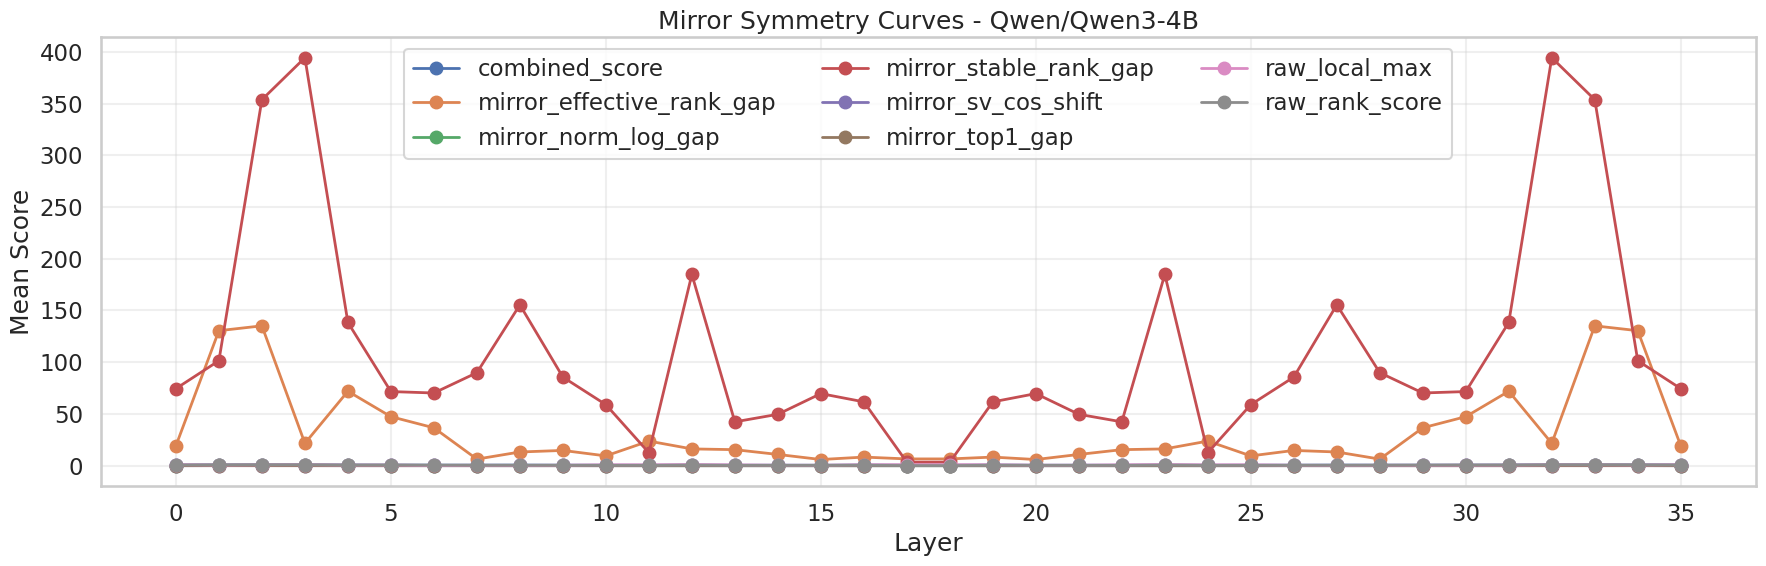

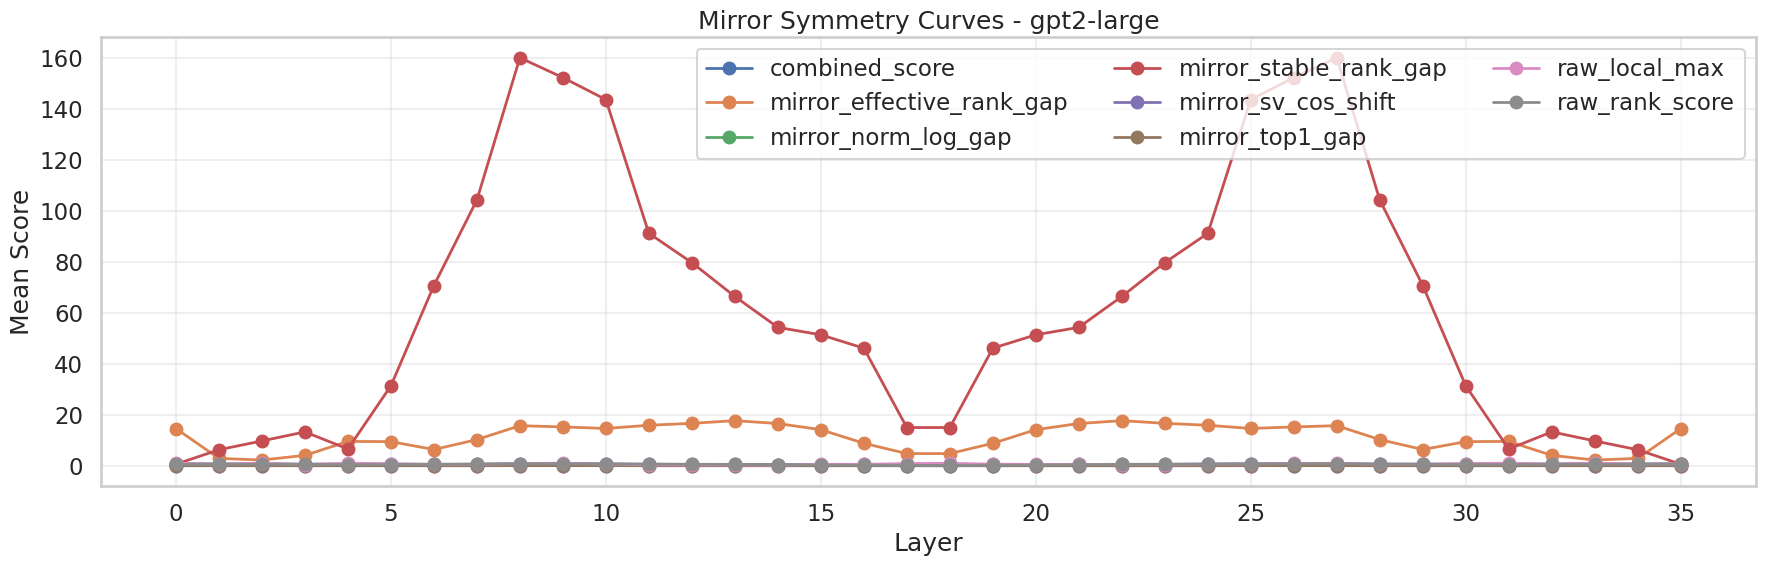

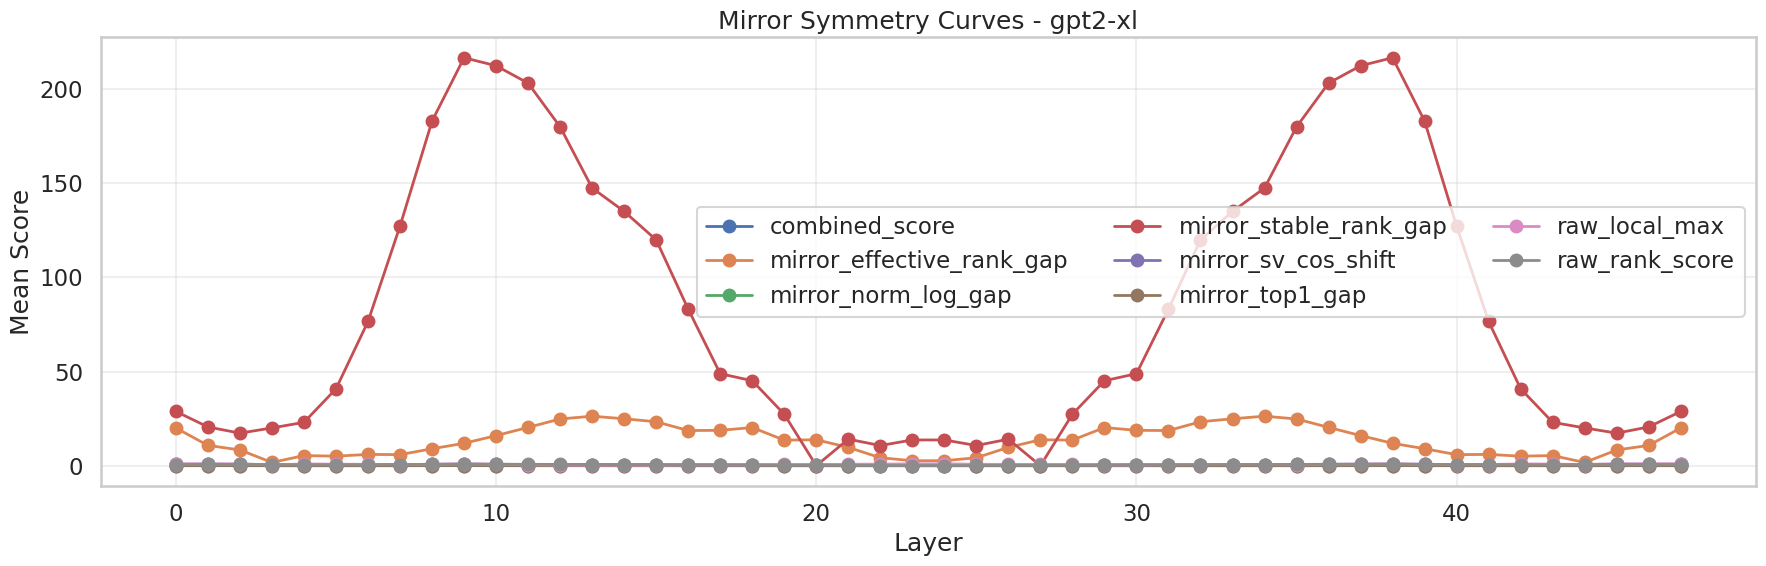

In [12]:
if not sym_df.empty:
    test_df = sym_df[sym_df['source'] == 'test'].copy()
    agg = (test_df.groupby(['model', 'metric', 'layer'])['value']
           .mean()
           .reset_index())

    for model in sorted(agg['model'].unique()):
        plt.figure(figsize=(18, 6))
        sub = agg[agg['model'] == model]
        for metric in sorted(sub['metric'].unique()):
            line = sub[sub['metric'] == metric]
            plt.plot(line['layer'], line['value'], marker='o', linewidth=2, label=metric)
        plt.title(f'Mirror Symmetry Curves - {model}')
        plt.xlabel('Layer')
        plt.ylabel('Mean Score')
        plt.legend(loc='best', ncol=3)
        plt.tight_layout()
        plt.show()

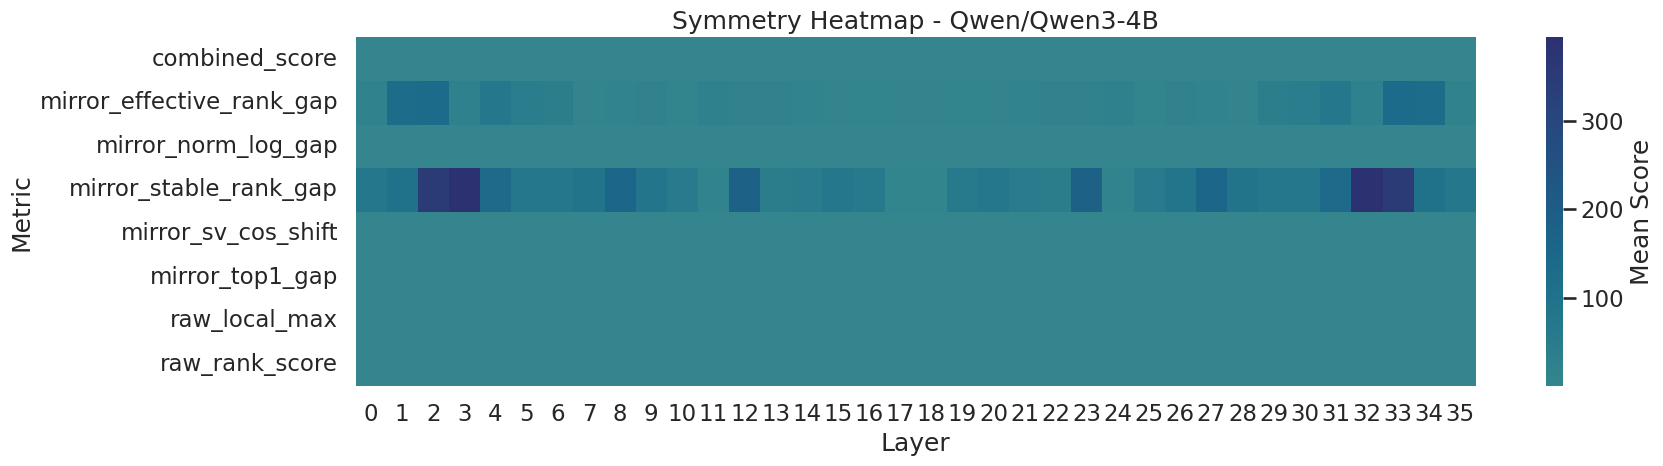

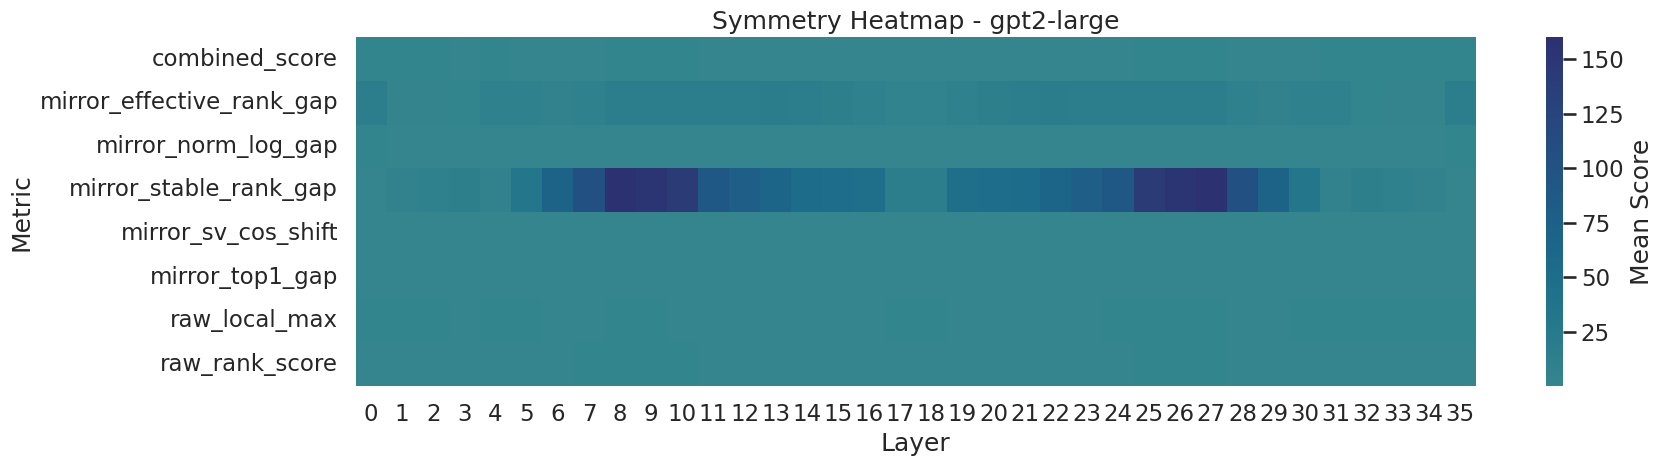

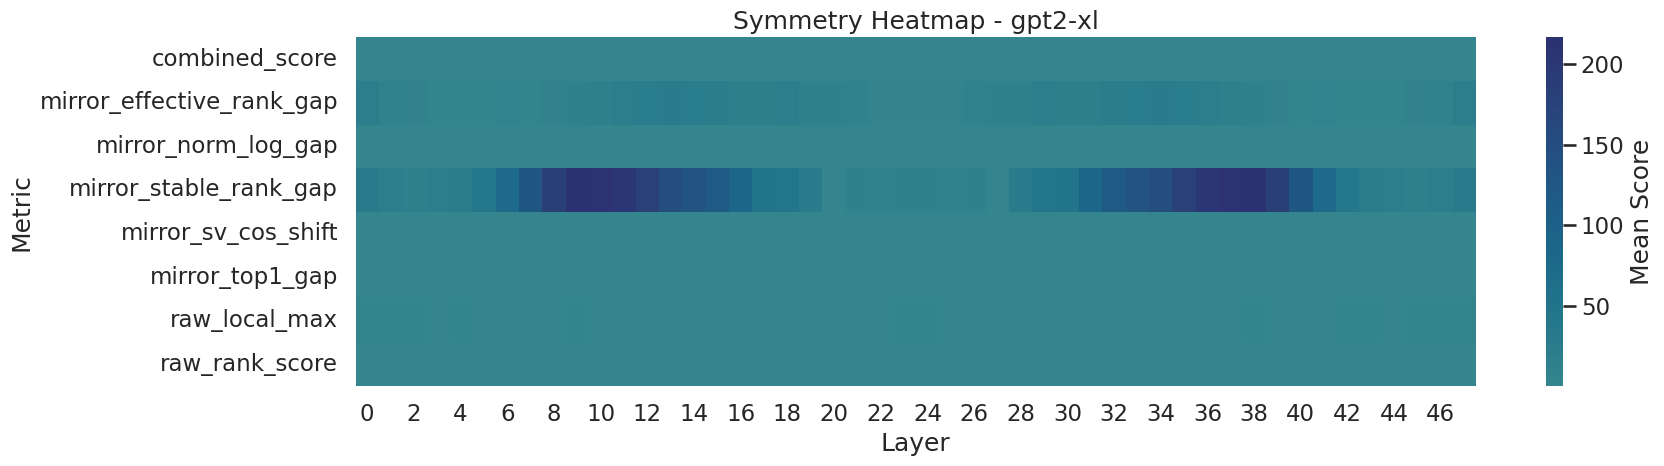

In [13]:
if not sym_df.empty:
    test_df = sym_df[sym_df['source'] == 'test']
    for model in sorted(test_df['model'].unique()):
        pivot = (test_df[test_df['model'] == model]
                 .groupby(['metric', 'layer'])['value']
                 .mean()
                 .unstack(fill_value=np.nan))
        plt.figure(figsize=(18, 5))
        sns.heatmap(pivot, cmap='crest', center=np.nanmedian(pivot.values), cbar_kws={'label': 'Mean Score'})
        plt.title(f'Symmetry Heatmap - {model}')
        plt.xlabel('Layer')
        plt.ylabel('Metric')
        plt.tight_layout()
        plt.show()

In [14]:
pred_frames = [collect_detection_predictions(p, detection_key='symmetry') for p in payloads]
pred_df = pd.concat(pred_frames, ignore_index=True) if pred_frames else pd.DataFrame()

if pred_df.empty:
    print('No prediction rows for symmetry detector.')
else:
    summary = pred_df.groupby('model').agg(
        n=('correct', 'size'),
        accuracy=('correct', 'mean'),
        mean_score=('detection_score', 'mean'),
    ).reset_index()
    display(summary)
    display(pred_df.head(20))

,model,n,accuracy,mean_score
0,Qwen/Qwen3-4B,106,0.0,0.879238
1,gpt2-large,106,0.0,0.804905
2,gpt2-xl,106,0.0,0.826560


,model,case_id,target_layer,predicted_layer,detection_score,correct
0,Qwen/Qwen3-4B,3,12,33,0.906000,False
1,Qwen/Qwen3-4B,4,12,33,0.882000,False
2,Qwen/Qwen3-4B,5,12,33,0.903143,False
3,Qwen/Qwen3-4B,0,12,32,0.861429,False
4,Qwen/Qwen3-4B,1,12,32,0.861429,False
5,Qwen/Qwen3-4B,2,12,32,0.861429,False
6,gpt2-xl,3,18,38,0.826915,False
7,gpt2-xl,4,18,38,0.826915,False
8,gpt2-xl,5,18,38,0.826915,False
9,gpt2-xl,0,18,38,0.826915,False
